In [1]:
# Load necessary library
library(fs)
library("ggplot2")
library("dplyr")



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
# Define base directories for the three nested directories
beta_dir1 <- "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta"  # Theoretical (eSMC Beta)
msmc_dir3 <- "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/MSMC2_out/msmc_beta/trial2"  # MSMC directory
esmc2_free <- "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_recomb_free"  # eSMC recombination-free directory

# List only directories in beta_dir1 that are two levels deep
beta_subdirs1 <- list.dirs(beta_dir1, recursive = TRUE, full.names = TRUE)
beta_subdirs1 <- beta_subdirs1[sapply(strsplit(beta_subdirs1, "/"), length) == length(strsplit(beta_dir1, "/")[[1]]) + 2]

# List only directories in msmc_dir3 that are one level deep
msmc_subdirs3 <- list.dirs(msmc_dir3, recursive = TRUE, full.names = TRUE)
msmc_subdirs3 <- msmc_subdirs3[sapply(strsplit(msmc_subdirs3, "/"), length) == length(strsplit(msmc_dir3, "/")[[1]]) + 2]

# List only directories in esmc2_free that are one level deep
esmc2_free_subdirs <- list.dirs(esmc2_free, recursive = TRUE, full.names = TRUE)
esmc2_free_subdirs <- esmc2_free_subdirs[sapply(strsplit(esmc2_free_subdirs, "/"), length) == length(strsplit(esmc2_free, "/")[[1]]) + 2]

# Initialize a list to store matches
beta_subdirs1

[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-10/alpha1.3"
 [2] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-10/alpha1.5"
 [3] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-10/alpha1.7"
 [4] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-10/alpha1.9"
 [5] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-6/alpha1.3" 
 [6] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-6/alpha1.5" 
 [7] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-6/alpha1.7" 
 [8] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-6/alpha1.9" 
 [9] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-7/alpha1.3" 
[10] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-7/alpha1.5" 
[11] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-7/alpha1.7" 
[12] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-7/alpha1.9" 
[13] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-8/alpha1.3" 
[14] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-8/alpha1.5" 
[15] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-8/alpha1.7" 
[16] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-8/alpha1.9" 
[17] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-9/alpha1.3" 
[18] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-9/alpha1.5" 
[19] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-9/alpha1.7" 
[20] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-9/alpha1.9"

In [3]:
# Initialize an empty vector to store second_to_last_beta_dir values
mut_r <- c()

# Loop through each theoretical directory (beta_dir1)
for (beta_dir in beta_subdirs1) {
  # Get the second-to-last directory name (e.g., "m1e-10")
  second_last_dir <- dirname(beta_dir)  # Get the parent directory
  second_to_last_beta_dir <- basename(second_last_dir)  # This gets the second-to-last directory name
  
  # Append the second_to_last_beta_dir to mut_r
  mut_r <- c(mut_r, second_to_last_beta_dir)
}

# Print the accumulated mut_r vector
mut_r<-unique(mut_r)


In [4]:
# Initialize an empty vector to store second_to_last_beta_dir values
mut_r <- c()

# Loop through each theoretical directory (beta_dir1) to extract unique `mut_r` values
for (beta_dir in beta_subdirs1) {
  # Get the second-to-last directory name (e.g., "m1e-10")
  second_last_dir <- dirname(beta_dir)  # Get the parent directory
  second_to_last_beta_dir <- basename(second_last_dir)  # Extract the second-to-last directory name
  
  # Append the second_to_last_beta_dir to mut_r
  mut_r <- c(mut_r, second_to_last_beta_dir)
}

# Ensure `mut_r` contains only unique values
mut_r <- unique(mut_r)

# Initialize an empty list to store three-way matches
three_way_matches <- list()

# Loop through each unique value in `mut_r`
for (current_mut_r in mut_r) {
  
  # Find matching beta directories based on `current_mut_r`
  matching_beta_dirs <- beta_subdirs1[grepl(current_mut_r, beta_subdirs1)]
  
  # Find matching MSMC directories based on `current_mut_r`
  matching_msmc_dirs <- msmc_subdirs3[grepl(current_mut_r, msmc_subdirs3)]
  
  # Find matching eSMC recombination-free directories based on `current_mut_r`
  matching_esmc2_free_dirs <- esmc2_free_subdirs[grepl(current_mut_r, esmc2_free_subdirs)]
  
  # Only add to matches if all three types of directories are found
  if (length(matching_beta_dirs) > 0 && length(matching_msmc_dirs) > 0 && length(matching_esmc2_free_dirs) > 0) {
    # Store the three-way matches for the current `mut_r`
    three_way_matches[[current_mut_r]] <- list(
      beta_dirs = matching_beta_dirs,
      msmc_dirs = matching_msmc_dirs,
      esmc2_free_dirs = matching_esmc2_free_dirs
    )
  }
}

# Display the three-way matches
print("Three-Way Matches:")
print(three_way_matches)




[1] "Three-Way Matches:"
$`m1e-10`
$`m1e-10`$beta_dirs
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-10/alpha1.3"
[2] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-10/alpha1.5"
[3] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-10/alpha1.7"
[4] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-10/alpha1.9"

$`m1e-10`$msmc_dirs
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/MSMC2_out/msmc_beta/trial2/m1e-10/alpha1.5"
[2] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/MSMC2_out/msmc_beta/trial2/m1e-10/alpha1.7"
[3] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/MSMC2_out

In [41]:
# Add a secondary loop for msmc_subdirs3 to find matches in esmc2_free_subdirs
for (msmc_dir in msmc_subdirs3) {
  second_to_last_msmc_dir <- basename(msmc_dir)  # This gets the last directory name for MSMC

  # Find matching eSMC recombination-free directories based on the last directory name
  matching_esmc2_free_dirs <- esmc2_free_subdirs[grepl(second_to_last_msmc_dir, esmc2_free_subdirs)]

  # If there are matches, store them
  if (length(matching_esmc2_free_dirs) > 0) {
    for (esmc2_free_dir in matching_esmc2_free_dirs) {
      # Initialize match list if it doesn't exist
      if (is.null(matches[[esmc2_free_dir]])) {
        matches[[esmc2_free_dir]] <- list(msmc_dirs = list(), beta_dirs = list())
      }
      matches[[esmc2_free_dir]]$msmc_dirs <- c(matches[[esmc2_free_dir]]$msmc_dirs, msmc_dir)
    }
  }
}

# Format the output for better readability
formatted_matches <- lapply(names(matches), function(match_key) {
  list(
    match_key = match_key,  # Directory key (MSMC or eSMC recombination-free)
    beta_dirs = matches[[match_key]]$beta_dirs,
    msmc_dirs = matches[[match_key]]$msmc_dirs,
    esmc2_free_dirs = matches[[match_key]]$esmc2_free_dirs
  )
})


ERROR: Error in matches[[esmc2_free_dir]]: object of type 'closure' is not subsettable


In [5]:
# Initialize a list to store the paths of .rds and .txt files
file_matches <- list()

# Loop through each unique key in the three_way_matches list
for (key in names(three_way_matches)) {
  # Extract the directories for the current key
  beta_dirs <- three_way_matches[[key]]$beta_dirs
  msmc_dirs <- three_way_matches[[key]]$msmc_dirs
  esmc2_free_dirs <- three_way_matches[[key]]$esmc2_free_dirs
  
  # Find .rds and .txt files in beta_dirs
  rds_txt_files_beta <- unlist(lapply(beta_dirs, function(beta_dir) {
    list.files(path = beta_dir, pattern = "\\.(rds)$", full.names = TRUE)
  }))
  
  # Find .rds and .txt files in msmc_dirs
  rds_txt_files_msmc <- unlist(lapply(msmc_dirs, function(msmc_dir) {
    list.files(path = msmc_dir, pattern = "\\.(txt)$", full.names = TRUE)
  }))
  
  # Find .rds and .txt files in esmc2_free_dirs
  rds_txt_files_esmc2_free <- unlist(lapply(esmc2_free_dirs, function(esmc2_free_dir) {
    list.files(path = esmc2_free_dir, pattern = "\\.(rds)$", full.names = TRUE)
  }))
  
  # Store the file paths in the structured list under the current key
  file_matches[[key]] <- list(
    beta_dirs = rds_txt_files_beta,
    msmc_dirs = rds_txt_files_msmc,
    esmc2_free_dirs = rds_txt_files_esmc2_free
  )
}

# Print the structured list of .rds and .txt files
print(file_matches)


$`m1e-10`
$`m1e-10`$beta_dirs
 [1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-10/alpha1.5/Beta_bottleneck_rep5_m1e-10_ratio999.9999999999999_rs1525230.vcf.rds"
 [2] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-10/alpha1.5/Beta_bottleneck_rep7_m1e-10_ratio999.9999999999999_rs1525232.vcf.rds"
 [3] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-10/alpha1.7/Beta_bottleneck_rep0_m1e-10_ratio999.9999999999999_rs1525225.vcf.rds"
 [4] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-10/alpha1.7/Beta_bottleneck_rep2_m1e-10_ratio999.9999999999999_rs1525227.vcf.rds"
 [5] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-10/alpha1.7/Beta_bottleneck_rep3

In [74]:
demography_data$years_ago

[1]      0.00000     20.90991     27.04340     34.97601     45.23550
 [6]     58.50439     75.66543     97.86030    126.56557    163.69094
[11]    211.70625    273.80586    354.12109    457.99511    592.33841
[16]    766.08851    990.80457   1281.43640   1657.31899   2143.45890
[21]   2772.19779   3585.36410   4637.05576   5997.23919   7756.40403
[26]  10031.58311  12974.13845  16779.83093  21701.84380  28067.62632
[31]  36300.67815  46948.72375  60720.15108  78531.13893 101566.60798
[36] 131359.05066 169890.48403 219724.30843 284175.84417 367532.89150

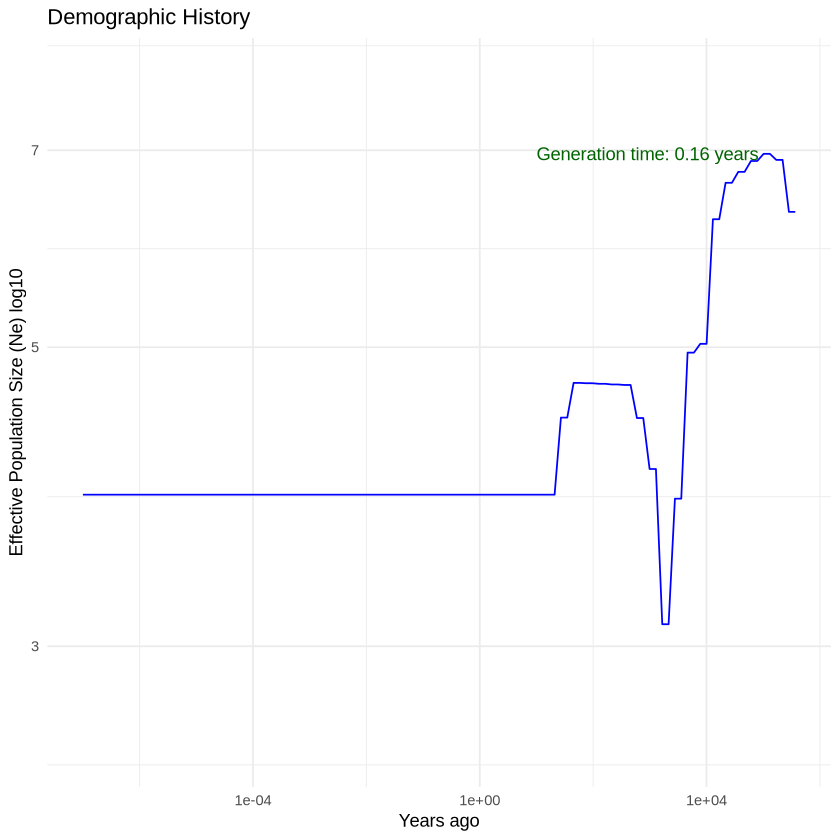

In [6]:

# Provided demography data
demography_data <- data.frame(
  years_ago = c(0.0000001, 20.90991, 27.04340, 34.97601, 45.23550, 58.50439,
                75.66543, 97.86030, 126.56557, 163.69094, 211.70625,
                273.80586, 354.12109, 457.99511, 592.33841, 766.08851,
                990.80457, 1281.43640, 1657.31899, 2143.45890, 2772.19779,
                3585.36410, 4637.05576, 5997.23919, 7756.40403, 10031.58311,
                12974.13845, 16779.83093, 21701.84380, 28067.62632, 36300.67815,
                46948.72375, 60720.15108, 78531.13893, 101566.60798, 131359.05066,
                169890.48403, 219724.30843, 284175.84417, 367532.89150),
  Ne_log10 = c(3.886466,3.886466, 4.433363, 4.433363, 4.704220, 4.704220,
               4.701291, 4.701291, 4.696954, 4.696954, 4.691536,
               4.691536, 4.687589, 4.687589, 4.430142, 4.430142,
               4.060712, 4.060712, 3.114804, 3.114804, 3.860018,
               3.860018, 4.953656, 4.953656, 5.028866, 5.028866,
               6.221847, 6.221847, 6.621246, 6.621246, 6.746056,
               6.746056, 6.872533, 6.872533, 6.957109, 6.957109,
               6.885372, 6.885372, 6.300497, 6.300497)
)

# Convert years_ago to generations_ago (assuming generation time of 0.16 years)

# Convert Ne_log10 to actual Ne values

# Plotting using ggplot2
ggplot(demography_data, aes(x = years_ago, y = Ne_log10)) +
  geom_line(color = "blue") +
  scale_x_log10() +
  scale_y_log10(limits = c(2.5, 8)) +  # Adjusting y-axis limits
  labs(title = "Demographic History",
       x = "Years ago",
       y = "Effective Population Size (Ne) log10") +
  theme_minimal() +
  annotate("text", x = 10, y = max(demography_data$Ne_log10, na.rm = TRUE), 
           label = "Generation time: 0.16 years", hjust = 0, color = "darkgreen")


##### Order of mutation rates stored

In [44]:
names(file_matches)

[1] "m1e-10" "m1e-6"  "m1e-7"  "m1e-8"  "m1e-9"

In [7]:
# Constants
mu <- 1e-10
gen_times <- 0.16

# Process files for each mutation rate (m1e-10, m1e-06, etc.)
for (mutation_rate_index in seq_along(file_matches)) {
  mutation_rate <- names(file_matches)[mutation_rate_index]
  print(paste0("Processing mutation_rate: ", mutation_rate))

  numeric_mutation_rate <- as.numeric(sub("m([0-9e.-]+)", "\\1", mutation_rate))
  print(paste("mutation rate numeric",numeric_mutation_rate))

  # Initialize sub-lists for 'esmc2', 'msmc2', and 'esmc2_free' within each mutation rate
  mutation_data <- list(
    esmc2 = list(),
    msmc2 = list(),
    esmc2_free = list()
  )
  
  # Debugging: Verify working directory inside and outside the loop
  print(paste("Current working directory inside the loop: ", getwd()))

  # Process 'esmc2' files for the current mutation rate
  for (j in seq_along(file_matches[[mutation_rate]]$beta_dirs)) {
    esmc2_dir <- file_matches[[mutation_rate]]$beta_dirs[j]
    
    # Split path to extract the alpha value
    path_components <- unlist(strsplit(esmc2_dir, "/"))
    alpha_simmed <- path_components[length(path_components) - 1]
  
    if (file.exists(esmc2_dir)) {
      # Debugging: Print the full path of the file being read
      print(paste("Reading file from path: ", esmc2_dir))
      
      # Print the normalized path to ensure it's correct
      print(paste("Normalized file path: ", normalizePath(esmc2_dir)))

      data_esmc2 <- readRDS(as.character(esmc2_dir))  # Read the .rds file
      
      # Debugging: Check the contents of the data read
      print("Contents of the data read from the RDS file:")
      print(data_esmc2)
      
      # Perform calculations for 'esmc2'
      Ne_t <- data_esmc2$Xi
      Ne <- mean(data_esmc2$mu / numeric_mutation_rate)
      
      data_esmc2$years_ago <- data_esmc2$Tc * Ne * gen_times
      data_esmc2$Ne <- log10(Ne_t * Ne)
      
      # Create a unique label using j and the base name of the file
      file_base_name <- basename(esmc2_dir)
      label <- paste0(j, "_", alpha_simmed, "_", file_base_name)
      
      # Store the results in the data frame
      mutation_data$esmc2[[label]] <- data.frame(
        years_ago = data_esmc2$years_ago,
        Ne = data_esmc2$Ne,
        alpha_sim = as.character(alpha_simmed)
      )
    } else {
      warning(paste("esmc2 directory does not exist:", esmc2_dir))
    }
  }

  # Process 'msmc2' files for the current mutation rate (only files with 'final.txt' suffix)
  msmc2_final_files <- file_matches[[mutation_rate]]$msmc_dirs[grep("final.txt$", file_matches[[mutation_rate]]$msmc_dirs)]
  for (j in seq_along(msmc2_final_files)) {
    msmc2_dir <- msmc2_final_files[j]
    
    # Split path to extract the alpha value
    path_components <- unlist(strsplit(msmc2_dir, "/"))
    alpha_simmed <- path_components[length(path_components) - 1]
    
    if (file.exists(msmc2_dir)) {
      # Debugging: Print the full path of the file being read
      print(paste("Reading file from path: ", msmc2_dir))
      
      # Read the .txt file
      data_msmc2 <- read.table(msmc2_dir, header = TRUE)  # Read the .txt file
      
      # Perform calculations for 'msmc2'
      data_msmc2$years_ago <- (data_msmc2$left_time_boundary) / numeric_mutation_rate * gen_times
      data_msmc2$Ne <- log10((1 / data_msmc2$lambda) / numeric_mutation_rate)
      
      # Create a unique label using j and the base name of the file
      file_base_name <- basename(msmc2_dir)
      label <- paste0(j, "_", alpha_simmed, "_", file_base_name)
      
      # Store the results in the data frame
      mutation_data$msmc2[[label]] <- data.frame(
        years_ago = data_msmc2$years_ago,
        Ne = data_msmc2$Ne,
        alpha_sim = as.character(alpha_simmed)
      )
    } else {
      warning(paste("msmc2 directory does not exist:", msmc2_dir))
    }
  }

  # Process 'esmc2_free' files for the current mutation rate
  for (j in seq_along(file_matches[[mutation_rate]]$esmc2_free)) {
    esmc2_free_dir <- file_matches[[mutation_rate]]$esmc2_free[j]
    
    # Split path to extract the alpha value
    path_components <- unlist(strsplit(esmc2_free_dir, "/"))
    alpha_simmed <- path_components[length(path_components) - 1]
    
    if (file.exists(esmc2_free_dir)) {
      # Debugging: Print the full path of the file being read
      print(paste("Reading file from path: ", esmc2_free_dir))
      
      data_esmc2_free <- readRDS(esmc2_free_dir)  # Read the .rds file
      
      # Perform calculations for 'esmc2_free'
      Ne_t <- data_esmc2_free$Xi
      Ne <- mean(data_esmc2_free$mu / numeric_mutation_rate)
      data_esmc2_free$years_ago <- data_esmc2_free$Tc * Ne * gen_times
      data_esmc2_free$Ne <- log10(Ne_t * Ne)
      
      # Create a unique label using j and the base name of the file
      file_base_name <- basename(esmc2_free_dir)
      label <- paste0(j, "_", alpha_simmed, "_", file_base_name)
      
      # Store the results in the data frame
      mutation_data$esmc2_free[[label]] <- data.frame(
        years_ago = data_esmc2_free$years_ago,
        Ne = data_esmc2_free$Ne,
        alpha_sim = as.character(alpha_simmed),
        rho=as.numeric(data_esmc2_free$rho),
        mu=as.numeric(data_esmc2_free$mu),
        r_m=as.numeric(data_esmc2_free$rho/data_esmc2_free$mu)

      )
    } else {
      warning(paste("esmc2_free directory does not exist:", esmc2_free_dir))
    }
  }
  
  # Dynamically assign the mutation_data to a variable based on the mutation rate
  variable_name <- paste0("individual_data_frames_", gsub("-", "_", mutation_rate))
  
  # Debugging: Check the variable name and assign the mutation data
  print(paste("Assigning mutation_data to variable: ", variable_name))
  
  assign(variable_name, mutation_data)
  print(paste0("Assigned mutation data to: ", variable_name))

}




[1] "Processing mutation_rate: m1e-10"
[1] "mutation rate numeric 1e-10"
[1] "Current working directory inside the loop:  /data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC"
[1] "Reading file from path:  /data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-10/alpha1.5/Beta_bottleneck_rep5_m1e-10_ratio999.9999999999999_rs1525230.vcf.rds"
[1] "Normalized file path:  /data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-10/alpha1.5/Beta_bottleneck_rep5_m1e-10_ratio999.9999999999999_rs1525230.vcf.rds"
[1] "Contents of the data read from the RDS file:"
$LH
[1] 429.1364

$Tc
 [1]  0.000000000  0.004273516  0.005460820  0.006977991  0.008916674
 [6]  0.011393979  0.014559549  0.018604604  0.023773490  0.030378439
[11]  0.038818431  0.049603290  0.063384490  0.080994497  0.103497063
[16]  0.132251480  0.168994689  0.215946202  0.2

In [8]:
# Reshape and combine esmc2 data for all alphas
all_esmc2_lines <- lapply(seq_along(individual_data_frames_m1e_10$esmc2), function(i) {
  df <- individual_data_frames_m1e_10$esmc2[[i]]
  rep_name <- names(individual_data_frames_m1e_10$esmc2)[i]  # Get the name of the current esmc2 data frame
  df %>%
    mutate(Rep = rep_name)       # Add Rep column with the current name
}) %>% bind_rows()  # Combine all esmc2 data frames into one

# Reshape and combine msmc2 data for all alphas
all_msmc2_lines <- lapply(seq_along(individual_data_frames_m1e_10$msmc2), function(i) {
  df <- individual_data_frames_m1e_10$msmc2[[i]]
  
  rep_name <- names(individual_data_frames_m1e_10$msmc2)[i]  # Get the name of the current msmc2 data frame
  df %>%
  mutate(Rep = rep_name)       # Add Rep column with the current name       # Add Rep column with the current name
}) %>% bind_rows()  # Combine all msmc2 data frames into one

# Reshape and combine esmc2_free data for all alphas
all_esmc2_free_lines <- lapply(seq_along(individual_data_frames_m1e_10$esmc2_free), function(i) {
  df <- individual_data_frames_m1e_10$esmc2_free[[i]]
  rep_name <- names(individual_data_frames_m1e_10$esmc2_free)[i]  # Get the name of the current esmc2_free data frame
  df %>%
  mutate(Rep = rep_name)       # Add Rep column with the current name
}) %>% bind_rows()  # Combine all esmc2_free data frames into one

all_esmc2_lines <- all_esmc2_lines[all_esmc2_lines$years_ago > 0, ]
all_esmc2_free_lines <- all_esmc2_free_lines[all_esmc2_free_lines$years_ago > 0, ]
all_msmc2_lines <- all_msmc2_lines[all_msmc2_lines$years_ago > 0, ]

In [64]:
names(individual_data_frames_m1e_7)

[1] "esmc2"      "msmc2"      "esmc2_free"

In [10]:
# Extract unique alpha values from the data
alphas <- unique(unlist(lapply(individual_data_frames_m1e_7$esmc2, function(x) unique(x$alpha_sim))))
alphas

[1] "alpha1.3" "alpha1.5" "alpha1.7" "alpha1.9"

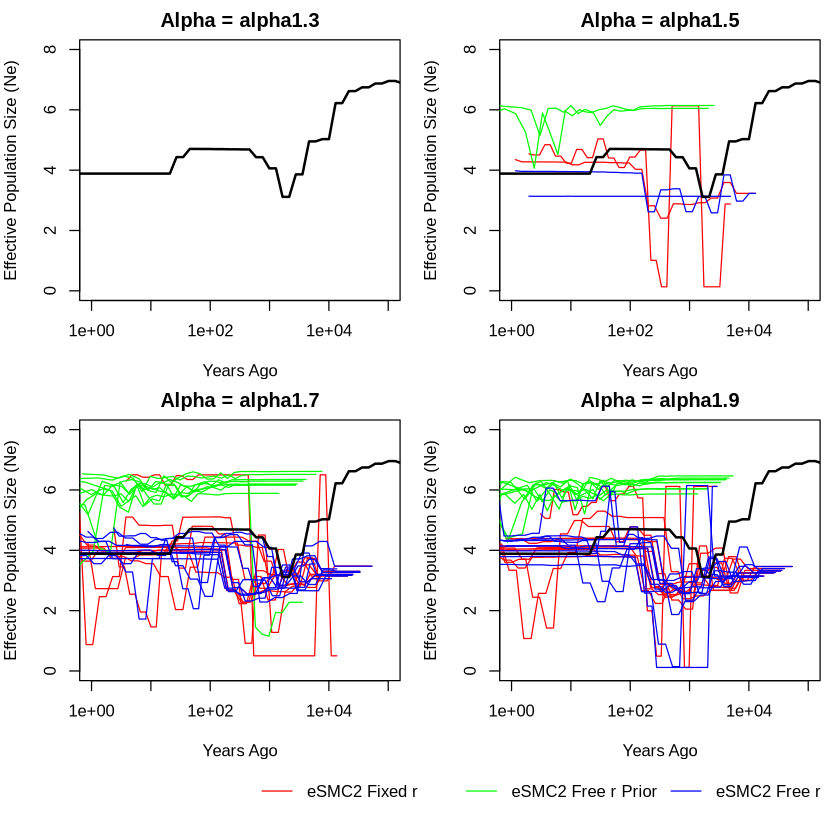

In [94]:
# Set up a 2x2 layout for 4 panels with space for a shared legend
par(mfrow = c(2, 2), mar = c(4, 4, 2, 1), oma = c(4, 0, 0, 0), bg = "white")

# Loop over each alpha to create a separate panel
for (alpha in alphas) {
  # Create an empty plot for this alpha
  plot(NULL, xlim = c(1, 100000), ylim = c(0, 8),
       log = "x", # Log-transform the x-axis
       xlab = "Years Ago", ylab = "Effective Population Size (Ne)",
       main = paste("Alpha =", alpha), col = "blue")
  
  # Plot data from smbc_fixed_r
  for (group_name in names(individual_data_frames_m1e_10$esmc2)) {
    # Extract the data frame and filter by alpha
    df_fixed <- individual_data_frames_m1e_10$esmc2[[group_name]]
    if (df_fixed$alpha_sim[1] == alpha) {
      # Add the line for this group
      lines(df_fixed$years_ago, df_fixed$Ne, type = "l", col = "red")
    }
  }
  
  # Plot data from smbc_free_r_prior
  for (group_name in names(individual_data_frames_m1e_10$msmc2)) {
    # Extract the data frame and filter by alpha
    df_free_prior <- individual_data_frames_m1e_10$msmc2[[group_name]]
    if (df_free_prior$alpha_sim[1] == alpha) {
      # Add the line for this group
      lines(df_free_prior$years_ago, df_free_prior$Ne, type = "l", col = "green")
    }
  }
  
  # Plot data from esmc2_free
  for (group_name in names(individual_data_frames_m1e_10$esmc2_free)) {
    # Extract the data frame and filter by alpha
    df_free <- individual_data_frames_m1e_10$esmc2_free[[group_name]]
    if (df_free$alpha_sim[1] == alpha) {
      # Add the line for this group
      lines(df_free$years_ago, df_free$Ne, type = "l", col = "blue")
    }
  }
  
  # Add the overall demography line
  lines(demography_data$years_ago, demography_data$Ne_log10, 
        type = "l", lty = 1, col = "black", lwd = 2)
}

# Add a single legend below the entire panel
par(xpd = NA)  # Allow drawing outside the plot region
legend("bottom", inset = c(0.2, -0.5), legend = c("eSMC2 Fixed r", "eSMC2 Free r Prior", "eSMC2 Free r", "Simulation"),
       col = c("red", "green", "blue", "black"), lty = c(1, 1, 1, 1), lwd = c(1, 1, 1, 2), horiz = TRUE, bty = "n")

# Reset plotting parameters to default
par(mfrow = c(2, 2), bg = "white", oma = c(0, 0, 0, 0))



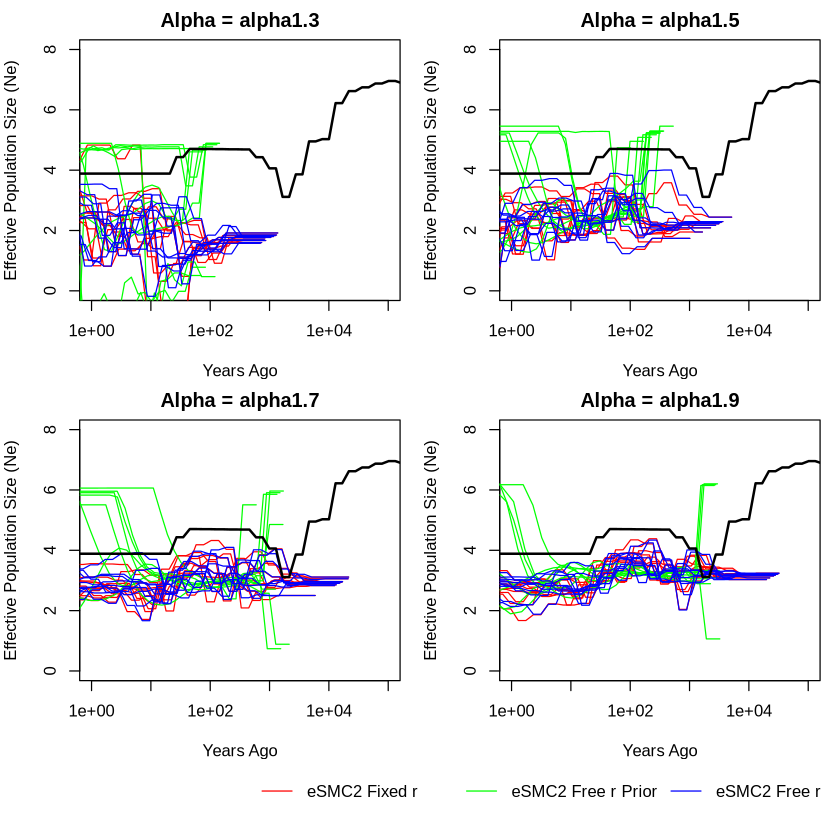

In [11]:
# Set up a 2x2 layout for 4 panels with space for a shared legend
par(mfrow = c(2, 2), mar = c(4, 4, 2, 1), oma = c(4, 0, 0, 0), bg = "white")

# Loop over each alpha to create a separate panel
for (alpha in alphas) {
  # Create an empty plot for this alpha
  plot(NULL, xlim = c(1, 100000), ylim = c(0, 8),
       log = "x", # Log-transform the x-axis
       xlab = "Years Ago", ylab = "Effective Population Size (Ne)",
       main = paste("Alpha =", alpha), col = "blue")
  
  # Plot data from smbc_fixed_r
  for (group_name in names(individual_data_frames_m1e_8$esmc2)) {
    # Extract the data frame and filter by alpha
    df_fixed <- individual_data_frames_m1e_8$esmc2[[group_name]]
    if (df_fixed$alpha_sim[1] == alpha) {
      # Add the line for this group
      lines(df_fixed$years_ago, df_fixed$Ne, type = "l", col = "red")
    }
  }
  
  # Plot data from smbc_free_r_prior
  for (group_name in names(individual_data_frames_m1e_8$msmc2)) {
    # Extract the data frame and filter by alpha
    df_free_prior <- individual_data_frames_m1e_8$msmc2[[group_name]]
    if (df_free_prior$alpha_sim[1] == alpha) {
      # Add the line for this group
      lines(df_free_prior$years_ago, df_free_prior$Ne, type = "l", col = "green")
    }
  }
  
  # Plot data from esmc2_free
  for (group_name in names(individual_data_frames_m1e_8$esmc2_free)) {
    # Extract the data frame and filter by alpha
    df_free <- individual_data_frames_m1e_8$esmc2_free[[group_name]]
    if (df_free$alpha_sim[1] == alpha) {
      # Add the line for this group
      lines(df_free$years_ago, df_free$Ne, type = "l", col = "blue")
    }
  }
  
  # Add the overall demography line
  lines(demography_data$years_ago, demography_data$Ne_log10, 
        type = "l", lty = 1, col = "black", lwd = 2)
}

# Add a single legend below the entire panel
par(xpd = NA)  # Allow drawing outside the plot region
legend("bottom", inset = c(0.2, -0.5), legend = c("eSMC2 Fixed r", "eSMC2 Free r Prior", "eSMC2 Free r", "Simulation"),
       col = c("red", "green", "blue", "black"), lty = c(1, 1, 1, 1), lwd = c(1, 1, 1, 2), horiz = TRUE, bty = "n")

# Reset plotting parameters to default
par(mfrow = c(2, 2), bg = "white", oma = c(0, 0, 0, 0))

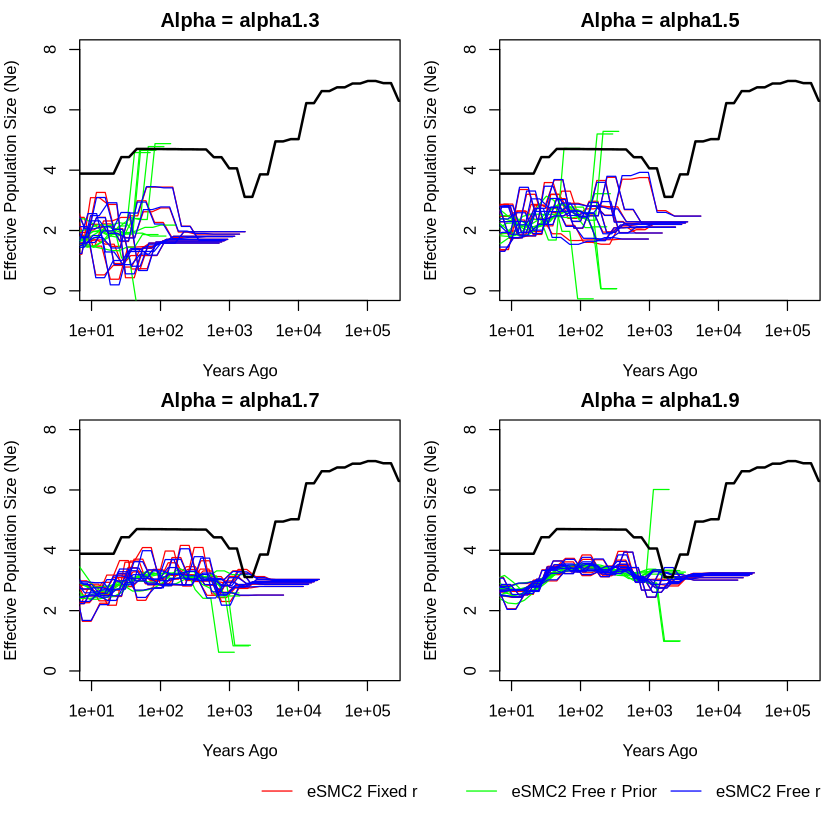

In [12]:
# Set up a 2x2 layout for 4 panels with space for a shared legend
par(mfrow = c(2, 2), mar = c(4, 4, 2, 1), oma = c(4, 0, 0, 0), bg = "white")

# Loop over each alpha to create a separate panel
for (alpha in alphas) {
  # Create an empty plot for this alpha
  plot(NULL, xlim = c(10, 200000), ylim = c(0, 8),
       log = "x", # Log-transform the x-axis
       xlab = "Years Ago", ylab = "Effective Population Size (Ne)",
       main = paste("Alpha =", alpha), col = "blue")
  
  # Plot data from smbc_fixed_r
  for (group_name in names(individual_data_frames_m1e_7$esmc2)) {
    # Extract the data frame and filter by alpha
    df_fixed <- individual_data_frames_m1e_7$esmc2[[group_name]]
    if (df_fixed$alpha_sim[1] == alpha) {
      # Add the line for this group
      lines(df_fixed$years_ago, df_fixed$Ne, type = "l", col = "red")
    }
  }
  
  # Plot data from smbc_free_r_prior
  for (group_name in names(individual_data_frames_m1e_7$msmc2)) {
    # Extract the data frame and filter by alpha
    df_free_prior <- individual_data_frames_m1e_7$msmc2[[group_name]]
    if (df_free_prior$alpha_sim[1] == alpha) {
      # Add the line for this group
      lines(df_free_prior$years_ago, df_free_prior$Ne, type = "l", col = "green")
    }
  }
  
  # Plot data from esmc2_free
  for (group_name in names(individual_data_frames_m1e_7$esmc2_free)) {
    # Extract the data frame and filter by alpha
    df_free <- individual_data_frames_m1e_7$esmc2_free[[group_name]]
    if (df_free$alpha_sim[1] == alpha) {
      # Add the line for this group
      lines(df_free$years_ago, df_free$Ne, type = "l", col = "blue")
    }
  }
  
  # Add the overall demography line
  lines(demography_data$years_ago, demography_data$Ne_log10, 
        type = "l", lty = 1, col = "black", lwd = 2)
}

# Add a single legend below the entire panel
par(xpd = NA)  # Allow drawing outside the plot region
legend("bottom", inset = c(0.2, -0.5), legend = c("eSMC2 Fixed r", "eSMC2 Free r Prior", "eSMC2 Free r", "Simulation"),
       col = c("red", "green", "blue", "black"), lty = c(1, 1, 1, 1), lwd = c(1, 1, 1, 2), horiz = TRUE, bty = "n")

# Reset plotting parameters to default
par(mfrow = c(2, 2), bg = "white", oma = c(0, 0, 0, 0))


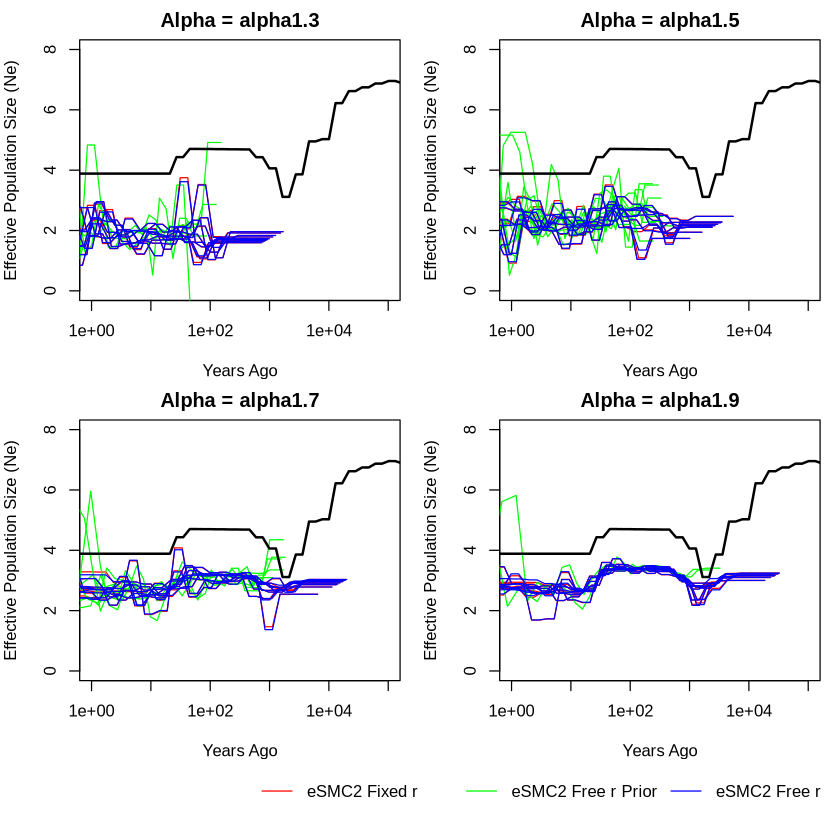

In [13]:
# Set up a 2x2 layout for 4 panels with space for a shared legend
par(mfrow = c(2, 2), mar = c(4, 4, 2, 1), oma = c(4, 0, 0, 0), bg = "white")

# Loop over each alpha to create a separate panel
for (alpha in alphas) {
  # Create an empty plot for this alpha
  plot(NULL, xlim = c(1, 100000), ylim = c(0, 8),
       log = "x", # Log-transform the x-axis
       xlab = "Years Ago", ylab = "Effective Population Size (Ne)",
       main = paste("Alpha =", alpha), col = "blue")
  
  # Plot data from smbc_fixed_r
  for (group_name in names(individual_data_frames_m1e_6$esmc2)) {
    # Extract the data frame and filter by alpha
    df_fixed <- individual_data_frames_m1e_6$esmc2[[group_name]]
    if (df_fixed$alpha_sim[1] == alpha) {
      # Add the line for this group
      lines(df_fixed$years_ago, df_fixed$Ne, type = "l", col = "red")
    }
  }
  
  # Plot data from smbc_free_r_prior
  for (group_name in names(individual_data_frames_m1e_6$msmc2)) {
    # Extract the data frame and filter by alpha
    df_free_prior <- individual_data_frames_m1e_6$msmc2[[group_name]]
    if (df_free_prior$alpha_sim[1] == alpha) {
      # Add the line for this group
      lines(df_free_prior$years_ago, df_free_prior$Ne, type = "l", col = "green")
    }
  }
  
  # Plot data from esmc2_free
  for (group_name in names(individual_data_frames_m1e_6$esmc2_free)) {
    # Extract the data frame and filter by alpha
    df_free <- individual_data_frames_m1e_6$esmc2_free[[group_name]]
    if (df_free$alpha_sim[1] == alpha) {
      # Add the line for this group
      lines(df_free$years_ago, df_free$Ne, type = "l", col = "blue")
    }
  }
  
  # Add the overall demography line
  lines(demography_data$years_ago, demography_data$Ne_log10, 
        type = "l", lty = 1, col = "black", lwd = 2)
}

# Add a single legend below the entire panel
par(xpd = NA)  # Allow drawing outside the plot region
legend("bottom", inset = c(0.2, -0.5), legend = c("eSMC2 Fixed r", "MSMC2", "eSMC2 Free r", "Simulation"),
       col = c("red", "green", "blue", "black"), lty = c(1, 1, 1, 1), lwd = c(1, 1, 1, 2), horiz = TRUE, bty = "n")

# Reset plotting parameters to default
par(mfrow = c(2, 2), bg = "white", oma = c(0, 0, 0, 0))

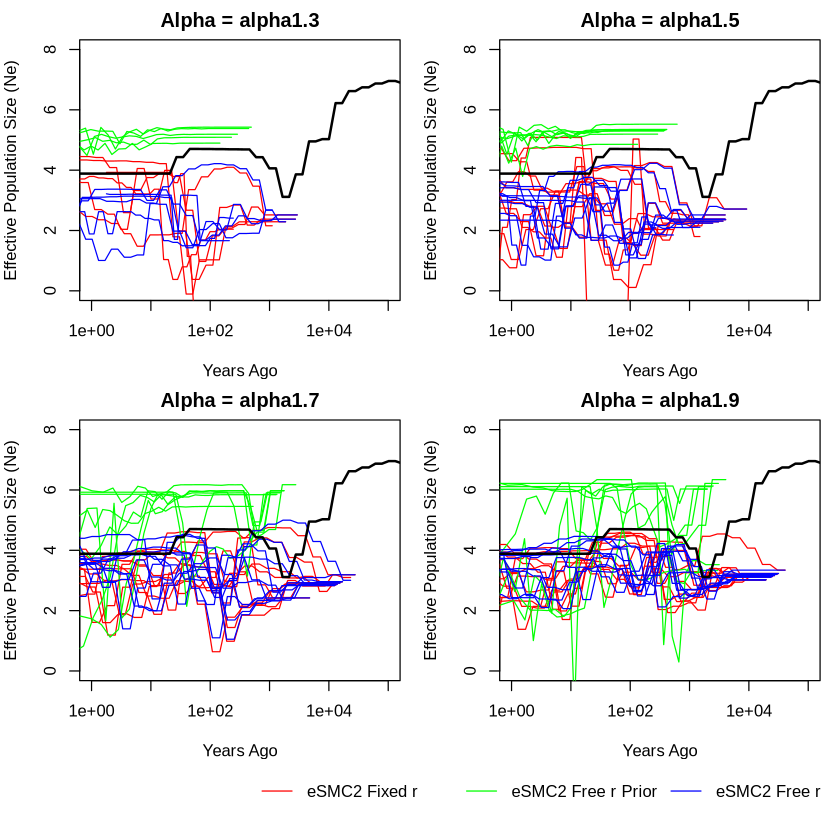

In [20]:
# Set up a 2x2 layout for 4 panels with space for a shared legend
par(mfrow = c(2, 2), mar = c(4, 4, 2, 1), oma = c(4, 0, 0, 0), bg = "white")

# Loop over each alpha to create a separate panel
for (alpha in alphas) {
  # Create an empty plot for this alpha
  plot(NULL, xlim = c(1, 100000), ylim = c(0, 8),
       log = "x", # Log-transform the x-axis
       xlab = "Years Ago", ylab = "Effective Population Size (Ne)",
       main = paste("Alpha =", alpha), col = "blue")
  
  # Plot data from smbc_fixed_r
  for (group_name in names(individual_data_frames_m1e_9$esmc2)) {
    # Extract the data frame and filter by alpha
    df_fixed <- individual_data_frames_m1e_9$esmc2[[group_name]]
    if (df_fixed$alpha_sim[1] == alpha) {
      # Add the line for this group
      lines(df_fixed$years_ago, df_fixed$Ne, type = "l", col = "red")
    }
  }
  
  # Plot data from smbc_free_r_prior
  for (group_name in names(individual_data_frames_m1e_9$msmc2)) {
    # Extract the data frame and filter by alpha
    df_free_prior <- individual_data_frames_m1e_9$msmc2[[group_name]]
    if (df_free_prior$alpha_sim[1] == alpha) {
      # Add the line for this group
      lines(df_free_prior$years_ago, df_free_prior$Ne, type = "l", col = "green")
    }
  }
  
  # Plot data from esmc2_free
  for (group_name in names(individual_data_frames_m1e_9$esmc2_free)) {
    # Extract the data frame and filter by alpha
    df_free <- individual_data_frames_m1e_9$esmc2_free[[group_name]]
    if (df_free$alpha_sim[1] == alpha) {
      # Add the line for this group
      lines(df_free$years_ago, df_free$Ne, type = "l", col = "blue")
    }
  }
  
  # Add the overall demography line
  lines(demography_data$years_ago, demography_data$Ne_log10, 
        type = "l", lty = 1, col = "black", lwd = 2)
}

# Add a single legend below the entire panel
par(xpd = NA)  # Allow drawing outside the plot region
legend("bottom", inset = c(0.2, -0.5), legend = c("eSMC2 Fixed r", "MSMC2", "eSMC2 Free r", "Simulation"),
       col = c("red", "green", "blue", "black"), lty = c(1, 1, 1, 1), lwd = c(1, 1, 1, 2), horiz = TRUE, bty = "n")

# Reset plotting parameters to default
par(mfrow = c(2, 2), bg = "white", oma = c(0, 0, 0, 0))

In [14]:
# Reshape and combine esmc2 data for all alphas
all_esmc2_lines <- lapply(seq_along(individual_data_frames_m1e_7$esmc2), function(i) {
  df <- individual_data_frames_m1e_7$esmc2[[i]]
  rep_name <- names(individual_data_frames_m1e_7$esmc2)[i]  # Get the name of the current esmc2 data frame
  df %>%
    mutate(Rep = rep_name)       # Add Rep column with the current name
}) %>% bind_rows()  # Combine all esmc2 data frames into one

# Reshape and combine msmc2 data for all alphas
all_msmc2_lines <- lapply(seq_along(individual_data_frames_m1e_7$msmc2), function(i) {
  df <- individual_data_frames_m1e_7$msmc2[[i]]
  
  rep_name <- names(individual_data_frames_m1e_7$msmc2)[i]  # Get the name of the current msmc2 data frame
  df %>%
  mutate(Rep = rep_name)       # Add Rep column with the current name       # Add Rep column with the current name
}) %>% bind_rows()  # Combine all msmc2 data frames into one

# Reshape and combine esmc2_free data for all alphas
all_esmc2_free_lines <- lapply(seq_along(individual_data_frames_m1e_7$esmc2_free), function(i) {
  df <- individual_data_frames_m1e_7$esmc2_free[[i]]
  rep_name <- names(individual_data_frames_m1e_7$esmc2_free)[i]  # Get the name of the current esmc2_free data frame
  df %>%
  mutate(Rep = rep_name)       # Add Rep column with the current name
}) %>% bind_rows()  # Combine all esmc2_free data frames into one

all_esmc2_lines <- all_esmc2_lines[all_esmc2_lines$years_ago > 0, ]
all_esmc2_free_lines <- all_esmc2_free_lines[all_esmc2_free_lines$years_ago > 0, ]
all_msmc2_lines <- all_msmc2_lines[all_msmc2_lines$years_ago > 0, ]

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message in transformation$transform(x):
“NaNs produced”
Warning message in scale_y_log10(limits = c(1.5, 8), breaks = scales::log_breaks()):
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_step()`).”
Warning message:
“Removed 71 rows containing missing values or values outside the scale range
(`geom_step()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_step()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_step()`).”
Warning message in transformation$transform(x):
“NaNs produced”
Warning message in scale_y_log10(limits = c(1.5, 8), breaks = scales::log_breaks()):
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 5 rows co

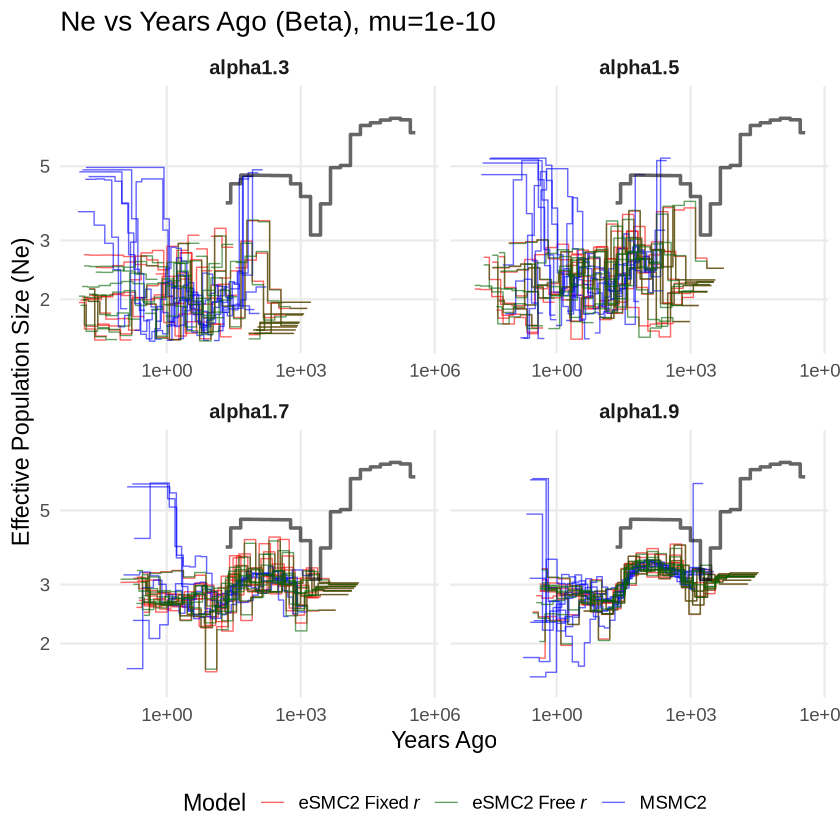

In [15]:
gg <- ggplot() +
  # Add step lines for beta data (color by alpha, group by Rep)
  geom_step(data = all_esmc2_lines,
            aes(x = years_ago, y = Ne, group = Rep, color = "ESMC2"), 
            size = 0.4, alpha = 0.6) +
  geom_step(data = all_msmc2_lines,
            aes(x = years_ago, y = Ne, group = Rep, color = "MSMC2"),
            size = 0.4, alpha = 0.6) +
  geom_step(data = all_esmc2_free_lines,
            aes(x = years_ago, y = Ne, group = Rep, color = "ESMC2 Free"), 
            size = 0.4, alpha = 0.6) +
  # Add the overall demography line as a step plot in black for each facet
  geom_step(data = demography_data,
            aes(x = years_ago, y = Ne_log10),
            color = "black", size = 1.0, alpha = 0.6) +
  # Set axes to log scale
  scale_x_log10(limits = c(0.01, 500000), breaks = scales::log_breaks()) +
  scale_y_log10(limits = c(1.5, 8), breaks = scales::log_breaks()) +
  # Use facet_wrap to create lattice-style subplots by alpha
  facet_wrap(~ alpha_sim, scales = "free_x", ncol = 2) +
  # Add labels and theme
  labs(
    x = "Years Ago",
    y = "Effective Population Size (Ne)",
    color = "Model",
    title = paste("Ne vs Years Ago (Beta), mu=1e-10")
  ) +
  # Define the custom color mapping for the legend
  scale_color_manual(
    values = c("ESMC2" = "red", "ESMC2 Free" = "darkgreen", "MSMC2" = "blue"),
    breaks = c("ESMC2", "ESMC2 Free", "MSMC2"),
    labels = c(expression("eSMC2 Fixed "*italic(r)), expression("eSMC2 Free "*italic(r)), "MSMC2")
  ) +
  theme_minimal(base_size = 14) +
  theme(
    strip.text = element_text(size = 12, face = "bold"),  # Facet labels
    legend.position = "bottom",
    panel.grid.minor = element_blank()
  ) +
  # Increase legend line thickness
  guides(color = guide_legend(override.aes = list(size = 2, linetype = 1)))  # Adjust legend line thickness and linetype

# Print the plot
print(gg)
ggsave("m1e10_sim.pdf", plot = gg, width = 10, height = 8)




Warning message in transformation$transform(x):
“NaNs produced”
Warning message in scale_y_log10(limits = c(1.5, 8), breaks = scales::log_breaks()):
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 146 rows containing missing values or values outside the scale range
(`geom_step()`).”
Warning message:
“Removed 69 rows containing missing values or values outside the scale range
(`geom_step()`).”
Warning message:
“Removed 146 rows containing missing values or values outside the scale range
(`geom_step()`).”
Warning message in transformation$transform(x):
“NaNs produced”
Warning message in scale_y_log10(limits = c(1.5, 8), breaks = scales::log_breaks()):
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 146 rows containing missing values or values outside the scale range
(`geom_step()`).”
Warning message:
“Removed 69 rows containing missing values or values outside the scale range
(`geom_step()`).”
Warning message:
“Removed 146 rows 

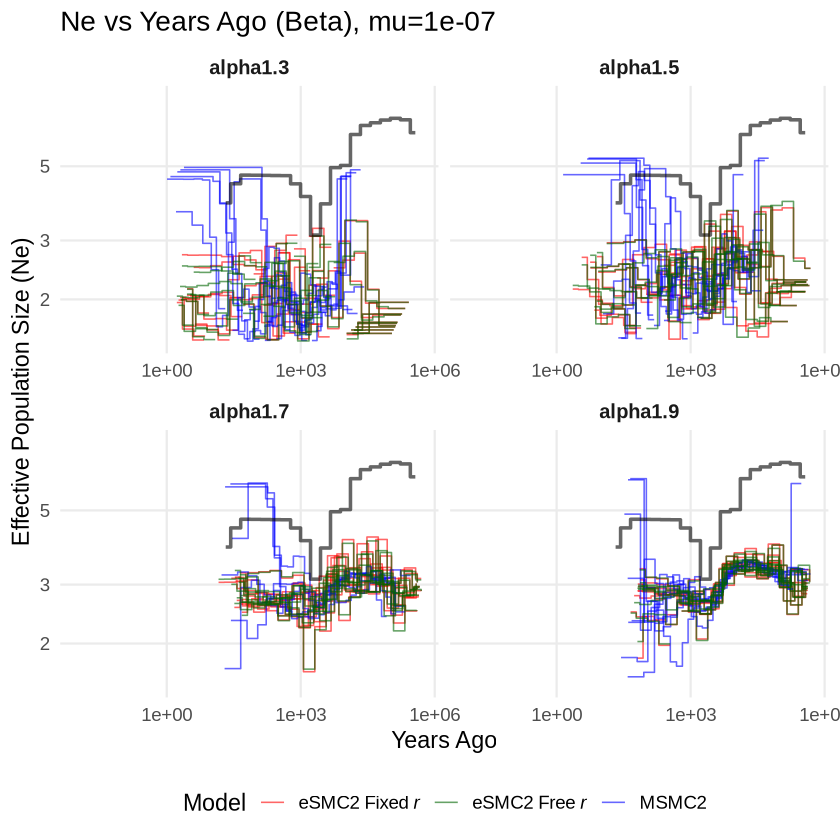

In [17]:
# Reshape and combine esmc2 data for all alphas
all_esmc2_lines <- lapply(seq_along(individual_data_frames_m1e_7$esmc2), function(i) {
  df <- individual_data_frames_m1e_7$esmc2[[i]]
  rep_name <- names(individual_data_frames_m1e_7$esmc2)[i]  # Get the name of the current esmc2 data frame
  df %>%
    mutate(Rep = rep_name)       # Add Rep column with the current name
}) %>% bind_rows()  # Combine all esmc2 data frames into one

# Reshape and combine msmc2 data for all alphas
all_msmc2_lines <- lapply(seq_along(individual_data_frames_m1e_7$msmc2), function(i) {
  df <- individual_data_frames_m1e_7$msmc2[[i]]
  
  rep_name <- names(individual_data_frames_m1e_7$msmc2)[i]  # Get the name of the current msmc2 data frame
  df %>%
  mutate(Rep = rep_name)       # Add Rep column with the current name       # Add Rep column with the current name
}) %>% bind_rows()  # Combine all msmc2 data frames into one

# Reshape and combine esmc2_free data for all alphas
all_esmc2_free_lines <- lapply(seq_along(individual_data_frames_m1e_7$esmc2_free), function(i) {
  df <- individual_data_frames_m1e_7$esmc2_free[[i]]
  rep_name <- names(individual_data_frames_m1e_7$esmc2_free)[i]  # Get the name of the current esmc2_free data frame
  df %>%
  mutate(Rep = rep_name)       # Add Rep column with the current name
}) %>% bind_rows()  # Combine all esmc2_free data frames into one

all_esmc2_lines <- all_esmc2_lines[all_esmc2_lines$years_ago > 0, ]
all_esmc2_free_lines <- all_esmc2_free_lines[all_esmc2_free_lines$years_ago > 0, ]
all_msmc2_lines <- all_msmc2_lines[all_msmc2_lines$years_ago > 0, ]


gg <- ggplot() +
  # Add step lines for beta data (color by alpha, group by Rep)
  geom_step(data = all_esmc2_lines,
            aes(x = years_ago, y = Ne, group = Rep, color = "ESMC2"), 
            size = 0.45, alpha = 0.6) +  # Adjust alpha here
  geom_step(data = all_msmc2_lines,
            aes(x = years_ago, y = Ne, group = Rep, color = "MSMC2"),
            size = 0.45, alpha = 0.6) +
  geom_step(data = all_esmc2_free_lines,
            aes(x = years_ago, y = Ne, group = Rep, color = "ESMC2 Free"), 
            size = 0.45, alpha = 0.6) +  # Adjust alpha here
  # Add the overall demography line as a step plot in black for each facet
  geom_step(data = demography_data,
            aes(x = years_ago, y = Ne_log10),
            color = "black", size = 1.0, alpha = 0.6) +  # Adjust alpha here
  # Set axes to log scale
  scale_x_log10(limits = c(0.01, 500000), breaks = scales::log_breaks()) +
  scale_y_log10(limits = c(1.5, 8), breaks = scales::log_breaks()) +
  # Use facet_wrap to create lattice-style subplots by alpha
  facet_wrap(~ alpha_sim, scales = "free_x", ncol = 2) +
  # Add labels and theme
  labs(
    x = "Years Ago",
    y = "Effective Population Size (Ne)",
    color = "Model",
    title = paste("Ne vs Years Ago (Beta), mu=1e-07")
  ) +
  # Define the custom color mapping for the legend
  scale_color_manual(
    values = c("ESMC2" = "red", "ESMC2 Free" = "darkgreen", "MSMC2" = "blue"),
    breaks = c("ESMC2", "ESMC2 Free", "MSMC2"),
    labels = c(expression("eSMC2 Fixed "*italic(r)), expression("eSMC2 Free "*italic(r)), "MSMC2")
  )  +
  # Customize legend appearance
  guides(color = guide_legend(
    override.aes = list(size = 5)  # Set line thickness for legend
  )) +
  theme_minimal(base_size = 14) +
  theme(
    strip.text = element_text(size = 12, face = "bold"),  # Facet labels
    legend.position = "bottom",
    panel.grid.minor = element_blank()
  )

# Print the ggplot
print(gg)
# Save the plot as a PDF
ggsave("m1e7_sim.pdf", plot = gg, width = 10, height = 8)



Warning message in transformation$transform(x):
“NaNs produced”
Warning message in scale_y_log10(limits = c(1.5, 8), breaks = scales::log_breaks()):
“log-10 transformation introduced infinite values.”
Warning message in transformation$transform(x):
“NaNs produced”
Warning message in scale_y_log10(limits = c(1.5, 8), breaks = scales::log_breaks()):
“log-10 transformation introduced infinite values.”
Warning message in transformation$transform(x):
“NaNs produced”
Warning message in scale_y_log10(limits = c(1.5, 8), breaks = scales::log_breaks()):
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 140 rows containing missing values or values outside the scale range
(`geom_step()`).”
Warning message:
“Removed 148 rows containing missing values or values outside the scale range
(`geom_step()`).”
Warning message:
“Removed 75 rows containing missing values or values outside the scale range
(`geom_step()`).”


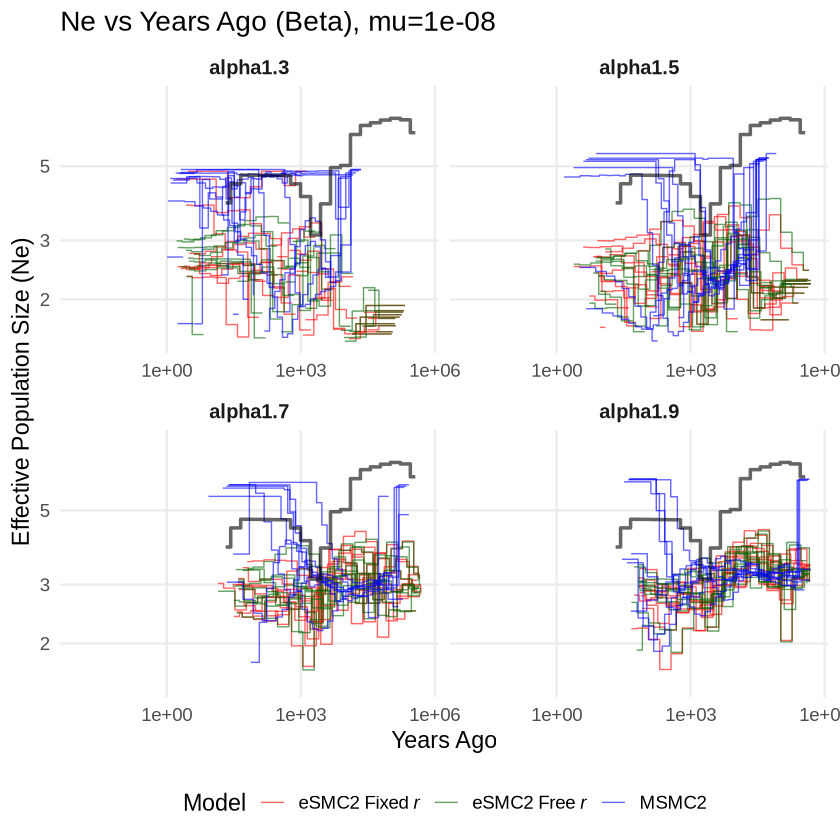

In [13]:
# Reshape and combine esmc2 data for all alphas
all_esmc2_lines <- lapply(seq_along(individual_data_frames_m1e_8$esmc2), function(i) {
  df <- individual_data_frames_m1e_8$esmc2[[i]]
  rep_name <- names(individual_data_frames_m1e_8$esmc2)[i]  # Get the name of the current esmc2 data frame
  df %>%
    mutate(Rep = rep_name)       # Add Rep column with the current name
}) %>% bind_rows()  # Combine all esmc2 data frames into one

# Reshape and combine msmc2 data for all alphas
all_msmc2_lines <- lapply(seq_along(individual_data_frames_m1e_8$msmc2), function(i) {
  df <- individual_data_frames_m1e_8$msmc2[[i]]
  
  rep_name <- names(individual_data_frames_m1e_8$msmc2)[i]  # Get the name of the current msmc2 data frame
  df %>%
  mutate(Rep = rep_name)       # Add Rep column with the current name       # Add Rep column with the current name
}) %>% bind_rows()  # Combine all msmc2 data frames into one

# Reshape and combine esmc2_free data for all alphas
all_esmc2_free_lines <- lapply(seq_along(individual_data_frames_m1e_8$esmc2_free), function(i) {
  df <- individual_data_frames_m1e_8$esmc2_free[[i]]
  rep_name <- names(individual_data_frames_m1e_8$esmc2_free)[i]  # Get the name of the current esmc2_free data frame
  df %>%
  mutate(Rep = rep_name)       # Add Rep column with the current name
}) %>% bind_rows()  # Combine all esmc2_free data frames into one

all_esmc2_lines <- all_esmc2_lines[all_esmc2_lines$years_ago > 0, ]
all_esmc2_free_lines <- all_esmc2_free_lines[all_esmc2_free_lines$years_ago > 0, ]
all_msmc2_lines <- all_msmc2_lines[all_msmc2_lines$years_ago > 0, ]


gg <- ggplot() +
  # Add step lines for beta data (color by alpha, group by Rep)
  geom_step(data = all_esmc2_lines,
            aes(x = years_ago, y = Ne, group = Rep, color = "ESMC2"), 
            size = 0.4, alpha = 0.6) +  # Adjust alpha here
  geom_step(data = all_esmc2_free_lines,
            aes(x = years_ago, y = Ne, group = Rep, color = "ESMC2 Free"), 
            size = 0.4, alpha = 0.6) +  # Adjust alpha here
  geom_step(data = all_msmc2_lines,
            aes(x = years_ago, y = Ne, group = Rep, color = "MSMC2"),
            size = 0.4, alpha = 0.6) +  # Adjust alpha here
  # Add the overall demography line as a step plot in black for each facet
  geom_step(data = demography_data,
            aes(x = years_ago, y = Ne_log10),
            color = "black", size = 1.0, alpha = 0.6) +  # Adjust alpha here
  # Set axes to log scale
  scale_x_log10(limits = c(0.01, 500000), breaks = scales::log_breaks()) +
  scale_y_log10(limits = c(1.5, 8), breaks = scales::log_breaks()) +
  # Use facet_wrap to create lattice-style subplots by alpha
  facet_wrap(~ alpha_sim, scales = "free_x", ncol = 2) +
  # Add labels and theme
  labs(
    x = "Years Ago",
    y = "Effective Population Size (Ne)",
    color = "Model",
    title = paste("Ne vs Years Ago (Beta), mu=1e-08")
  ) +
  # Define the custom color mapping for the legend
  scale_color_manual(
    values = c("ESMC2" = "red", "ESMC2 Free" = "darkgreen", "MSMC2" = "blue"),
    breaks = c("ESMC2", "ESMC2 Free", "MSMC2"),
    labels = c(expression("eSMC2 Fixed "*italic(r)), expression("eSMC2 Free "*italic(r)), "MSMC2")
  ) +
  # Customize legend appearance
  guides(color = guide_legend(
    override.aes = list(size = 5)  # Set line thickness for legend
  )) +
  theme_minimal(base_size = 14) +
  theme(
    strip.text = element_text(size = 12, face = "bold"),  # Facet labels
    legend.position = "bottom",
    panel.grid.minor = element_blank()
  )

# Print the ggplot
print(gg)


In [14]:
# Reshape and combine esmc2 data for all alphas (1e-06 mutation rate)
all_esmc2_lines <- lapply(seq_along(individual_data_frames_m1e_6$esmc2), function(i) {
  df <- individual_data_frames_m1e_6$esmc2[[i]]
  rep_name <- names(individual_data_frames_m1e_6$esmc2)[i]  # Get the name of the current esmc2 data frame
  df %>%
    mutate(Rep = rep_name)       # Add Rep column with the current name
}) %>% bind_rows()  # Combine all esmc2 data frames into one

# Reshape and combine msmc2 data for all alphas (1e-06 mutation rate)
all_msmc2_lines <- lapply(seq_along(individual_data_frames_m1e_6$msmc2), function(i) {
  df <- individual_data_frames_m1e_6$msmc2[[i]]
  rep_name <- names(individual_data_frames_m1e_6$msmc2)[i]  # Get the name of the current msmc2 data frame
  df %>%
    mutate(Rep = rep_name)       # Add Rep column with the current name
}) %>% bind_rows()  # Combine all msmc2 data frames into one

# Reshape and combine esmc2_free data for all alphas (1e-06 mutation rate)
all_esmc2_free_lines <- lapply(seq_along(individual_data_frames_m1e_6$esmc2_free), function(i) {
  df <- individual_data_frames_m1e_6$esmc2_free[[i]]
  rep_name <- names(individual_data_frames_m1e_6$esmc2_free)[i]  # Get the name of the current esmc2_free data frame
  df %>%
    mutate(Rep = rep_name)       # Add Rep column with the current name
}) %>% bind_rows()  # Combine all esmc2_free data frames into one

# Filter out rows where years_ago <= 0 for mutation rate 1e-06
all_esmc2_lines <- all_esmc2_lines[all_esmc2_lines$years_ago > 0, ]
all_esmc2_free_lines <- all_esmc2_free_lines[all_esmc2_free_lines$years_ago > 0, ]
all_msmc2_lines <- all_msmc2_lines[all_msmc2_lines$years_ago > 0, ]



Warning message in transformation$transform(x):
“NaNs produced”
Warning message in scale_y_log10(limits = c(1.5, 8), breaks = scales::log_breaks()):
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 140 rows containing missing values or values outside the scale range
(`geom_step()`).”
Warning message:
“Removed 140 rows containing missing values or values outside the scale range
(`geom_step()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_step()`).”


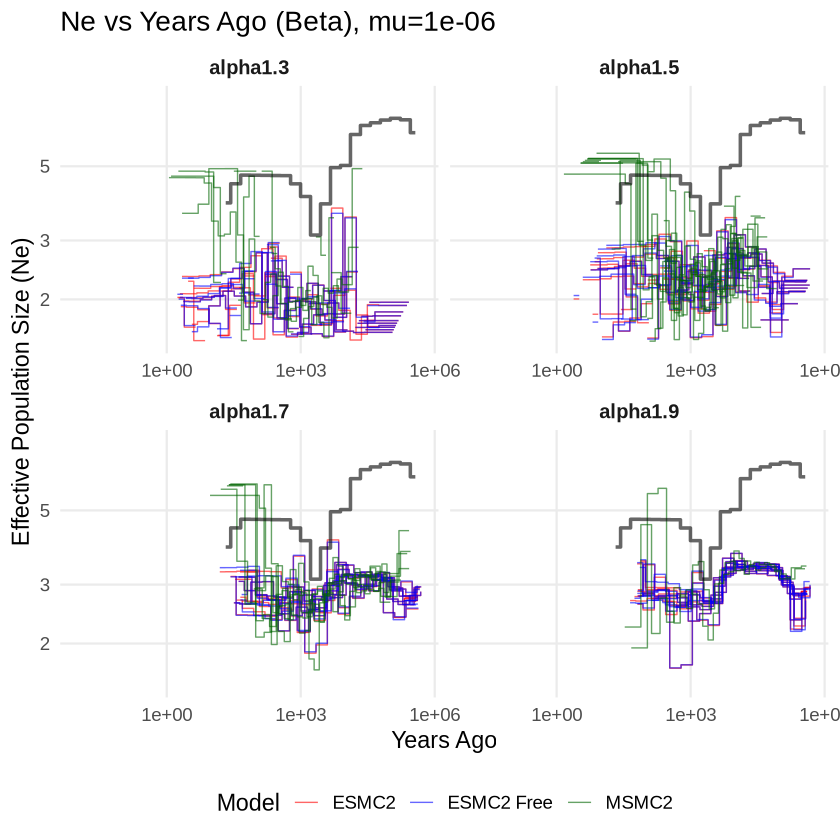

In [15]:
# Create the step plot with facets and proper legend
gg <- ggplot() +
  # Add step lines for beta data (color by alpha, group by Rep)
  geom_step(data = all_esmc2_lines,
            aes(x = years_ago, y = Ne, group = Rep, color = "ESMC2"), 
            size = 0.4, alpha = 0.6) +  # Adjust alpha here
  geom_step(data = all_esmc2_free_lines,
            aes(x = years_ago, y = Ne, group = Rep, color = "ESMC2 Free"), 
            size = 0.4, alpha = 0.6) +  # Adjust alpha here
  geom_step(data = all_msmc2_lines,
            aes(x = years_ago, y = Ne, group = Rep, color = "MSMC2"),
            size = 0.4, alpha = 0.6) +  # Adjust alpha here
  # Add the overall demography line as a step plot in black for each facet
  geom_step(data = demography_data,
            aes(x = years_ago, y = Ne_log10),
            color = "black", size = 1.0, alpha = 0.6) +  # Adjust alpha here
  # Set axes to log scale
  scale_x_log10(limits = c(0.01, 500000), breaks = scales::log_breaks()) +
  scale_y_log10(limits = c(1.5, 8), breaks = scales::log_breaks()) +
  # Use facet_wrap to create lattice-style subplots by alpha
  facet_wrap(~ alpha_sim, scales = "free_x", ncol = 2) +
  # Add labels and theme
  labs(
    x = "Years Ago",
    y = "Effective Population Size (Ne)",
    color = "Model",
    title = paste("Ne vs Years Ago (Beta), mu=1e-06")
  ) +
  # Define the custom color mapping for the legend
  scale_color_manual(
    values = c("ESMC2" = "red", "ESMC2 Free" = "blue", "MSMC2" = "darkgreen", "black" = "black"),
    breaks = c("ESMC2", "ESMC2 Free", "MSMC2", "black"),
    labels = c("ESMC2", "ESMC2 Free", "MSMC2", "Demography")
  ) +
  theme_minimal(base_size = 14) +
  theme(
    strip.text = element_text(size = 12, face = "bold"),  # Facet labels
    legend.position = "bottom",
    panel.grid.minor = element_blank()
  )

# Print the ggplot
print(gg)


In [186]:
# Reshape and combine esmc2 data for all alphas (1e-06 mutation rate)
all_esmc2_lines <- lapply(seq_along(individual_data_frames_m1e_7$esmc2), function(i) {
  df <- individual_data_frames_m1e_7$esmc2[[i]]
  rep_name <- names(individual_data_frames_m1e_7$esmc2)[i]  # Get the name of the current esmc2 data frame
  df %>%
    mutate(Rep = rep_name)       # Add Rep column with the current name
}) %>% bind_rows()  # Combine all esmc2 data frames into one

# Reshape and combine msmc2 data for all alphas (1e-06 mutation rate)
all_msmc2_lines <- lapply(seq_along(individual_data_frames_m1e_7$msmc2), function(i) {
  df <- individual_data_frames_m1e_7$msmc2[[i]]
  rep_name <- names(individual_data_frames_m1e_7$msmc2)[i]  # Get the name of the current msmc2 data frame
  df %>%
    mutate(Rep = rep_name)       # Add Rep column with the current name
}) %>% bind_rows()  # Combine all msmc2 data frames into one

# Reshape and combine esmc2_free data for all alphas (1e-06 mutation rate)
all_esmc2_free_lines <- lapply(seq_along(individual_data_frames_m1e_7$esmc2_free), function(i) {
  df <- individual_data_frames_m1e_7$esmc2_free[[i]]
  rep_name <- names(individual_data_frames_m1e_7$esmc2_free)[i]  # Get the name of the current esmc2_free data frame
  df %>%
    mutate(Rep = rep_name)       # Add Rep column with the current name
}) %>% bind_rows()  # Combine all esmc2_free data frames into one

# Filter out rows where years_ago <= 0 for mutation rate 1e-06
all_esmc2_lines <- all_esmc2_lines[all_esmc2_lines$years_ago > 0, ]
all_esmc2_free_lines <- all_esmc2_free_lines[all_esmc2_free_lines$years_ago > 0, ]
all_msmc2_lines <- all_msmc2_lines[all_msmc2_lines$years_ago > 0, ]


Warning message in transformation$transform(x):
“NaNs produced”
Warning message in scale_y_log10(limits = c(1.5, 8), breaks = scales::log_breaks()):
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_step()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_step()`).”
Warning message:
“Removed 71 rows containing missing values or values outside the scale range
(`geom_step()`).”


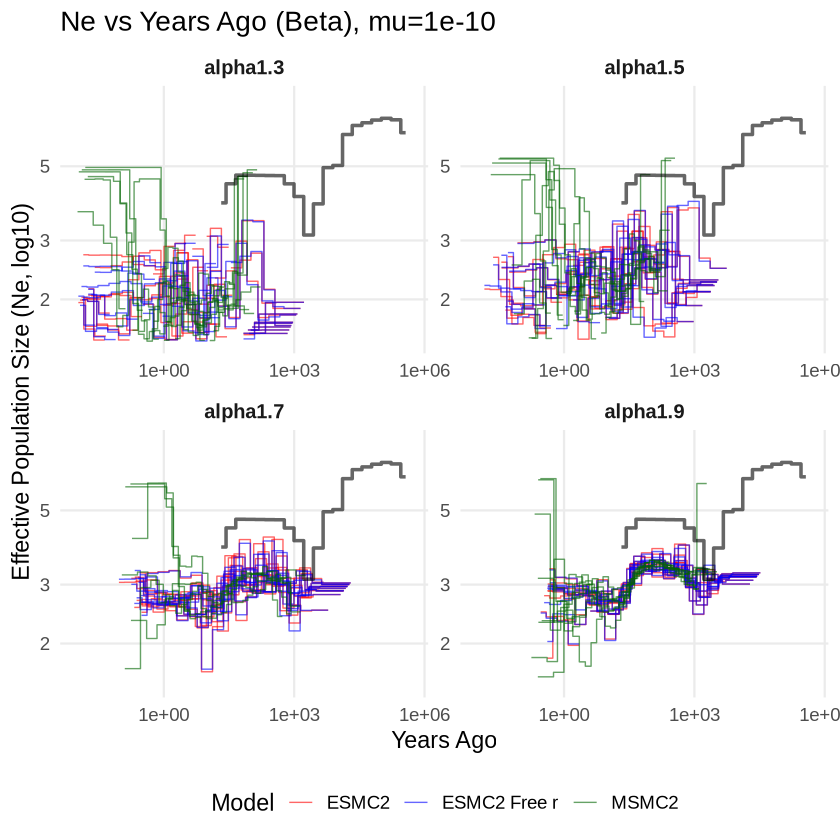

In [198]:
# Create the step plot with facets and proper legend
gg <- ggplot() +
  # Add step lines for beta data (color by alpha, group by Rep)
  geom_step(data = all_esmc2_lines,
            aes(x = years_ago, y = Ne, group = Rep, color = "ESMC2"), 
            size = 0.4, alpha = 0.6) +  # Adjust alpha here
  geom_step(data = all_esmc2_free_lines,
            aes(x = years_ago, y = Ne, group = Rep, color = "ESMC2 Free r"), 
            size = 0.4, alpha = 0.6) +  # Adjust alpha here
  geom_step(data = all_msmc2_lines,
            aes(x = years_ago, y = Ne, group = Rep, color = "MSMC2"),
            size = 0.4, alpha = 0.6) +  # Adjust alpha here
  # Add the overall demography line as a step plot in black for each facet
  geom_step(data = demography_data,
            aes(x = years_ago, y = Ne_log10),
            color = "black", size = 1.0, alpha = 0.6) +  # Adjust alpha here
  # Set axes to log scale
  scale_x_log10(limits = c(0.01, 500000), breaks = scales::log_breaks()) +
  scale_y_log10(limits = c(1.5, 8), breaks = scales::log_breaks()) +
  # Use facet_wrap to create lattice-style subplots by alpha
  facet_wrap(~ alpha_sim, scales = "free", ncol = 2) +
  # Add labels and theme
  labs(
    x = "Years Ago",
    y = "Effective Population Size (Ne, log10)",
    color = "Model",
    title = paste("Ne vs Years Ago (Beta), mu=1e-10")
  ) +
  # Define the custom color mapping for the legend
  scale_color_manual(
    values = c("ESMC2" = "red", "ESMC2 Free r" = "blue", "MSMC2" = "darkgreen", "black" = "black"),
    breaks = c("ESMC2", "ESMC2 Free r", "MSMC2", "black"),
    labels = c("ESMC2", "ESMC2 Free r", "MSMC2", "Demography")
  ) +
  theme_minimal(base_size = 14) +
  theme(
    strip.text = element_text(size = 12, face = "bold"),  # Facet labels
    legend.position = "bottom",
    panel.grid.minor = element_blank()
  )

# Print the ggplot
print(gg)


In [16]:
# List of mutation rates and corresponding data frames
mutation_rates <- c("m1e_6", "m1e_7", "m1e_8", "m1e_9", "m1e_10")

# Create an empty data frame to store all the data for plotting
all_data <- data.frame()

# Define different y-limits for each facet (mutation rate)
y_limits_list <- list(
  "m1e_6" = c(0, 10),
  "m1e_7" = c(0, 3),
  "m1e_8" = c(0, 500),
  "m1e_9" = c(0, 6000),
  "m1e_10" = c(0, 12000)
)

# Loop through each mutation rate and process the data
for (mutation_rate in mutation_rates) {
  
  # Extract the corresponding mutation data (using the assigned variable names)
  mutation_data <- get(paste0("individual_data_frames_", mutation_rate))
  
  # For the esmc2_free model, extract the necessary variables
  df <- mutation_data$esmc2_free
  
  # Check if there are any data for the esmc2_free model
  if (length(df) > 0) {
    # Add the mutation rate and replicate info
    model_data <- bind_rows(lapply(names(df), function(rep_name) {
      data <- df[[rep_name]]
      data %>%
        mutate(
          Model = "esmc2_free",            # Set model name as esmc2_free
          MutationRate = mutation_rate,    # Add mutation rate
          Replicate = rep_name             # Add replicate name
        )
    }))
    
    # Combine model data with the all_data data frame
    all_data <- bind_rows(all_data, model_data)
  }
}


# Modify the 'alpha_sim' column to remove "alpha" and keep only the numbers
all_data$alpha_sim <- gsub("alpha_", "", all_data$alpha_sim)  # Remove 'alpha_' from the label
all_data$alpha_sim <- factor(all_data$alpha_sim, levels = sort(unique(all_data$alpha_sim)))  # Sort alphas in ascending order

# Define custom x-tick labels for alpha
x_labels <- c(expression(alpha == 1.3), expression(alpha == 1.5), expression(alpha == 1.7), expression(alpha == 1.9))  # Example custom labels for the x-axis

# Ensure MutationRate is a factor with levels in the desired order
all_data$MutationRate <- factor(all_data$MutationRate, levels = mutation_rates)
# View the structure of the data
head(all_data)


,years_ago,Ne,alpha_sim,rho,mu,r_m,Model,MutationRate,Replicate
,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<chr>,<fct>,<chr>
1,0.00000000,2.317031,alpha1.3,5.844432e-06,6.839931e-05,0.08544578,esmc2_free,m1e_6,1_alpha1.3_Beta_bottleneck_rep0_m1e-06_ratio0.1_rs1525225.vcf.rds
2,0.01925216,2.317031,alpha1.3,5.844432e-06,6.839931e-05,0.08544578,esmc2_free,m1e_6,1_alpha1.3_Beta_bottleneck_rep0_m1e-06_ratio0.1_rs1525225.vcf.rds
3,0.02577744,1.449951,alpha1.3,5.844432e-06,6.839931e-05,0.08544578,esmc2_free,m1e_6,1_alpha1.3_Beta_bottleneck_rep0_m1e-06_ratio0.1_rs1525225.vcf.rds
4,0.03451438,1.449951,alpha1.3,5.844432e-06,6.839931e-05,0.08544578,esmc2_free,m1e_6,1_alpha1.3_Beta_bottleneck_rep0_m1e-06_ratio0.1_rs1525225.vcf.rds
5,0.04621259,1.429178,alpha1.3,5.844432e-06,6.839931e-05,0.08544578,esmc2_free,m1e_6,1_alpha1.3_Beta_bottleneck_rep0_m1e-06_ratio0.1_rs1525225.vcf.rds
6,0.06187576,1.429178,alpha1.3,5.844432e-06,6.839931e-05,0.08544578,esmc2_free,m1e_6,1_alpha1.3_Beta_bottleneck_rep0_m1e-06_ratio0.1_rs1525225.vcf.rds


In [17]:
# Add a new column with the y-limits based on the MutationRate
all_data <- all_data %>%
  mutate(
    ymin = sapply(MutationRate, function(x) y_limits_list[[as.character(x)]][1]),
    ymax = sapply(MutationRate, function(x) y_limits_list[[as.character(x)]][2])
  )
head(all_data)
# Filter the data based on the y-limits for each mutation rate
all_data_filtered <- all_data %>%
  filter(r_m >= ymin & r_m <= ymax)



,years_ago,Ne,alpha_sim,rho,mu,r_m,Model,MutationRate,Replicate,ymin,ymax
,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<chr>,<fct>,<chr>,<dbl>,<dbl>
1,0.00000000,2.317031,alpha1.3,5.844432e-06,6.839931e-05,0.08544578,esmc2_free,m1e_6,1_alpha1.3_Beta_bottleneck_rep0_m1e-06_ratio0.1_rs1525225.vcf.rds,0,10
2,0.01925216,2.317031,alpha1.3,5.844432e-06,6.839931e-05,0.08544578,esmc2_free,m1e_6,1_alpha1.3_Beta_bottleneck_rep0_m1e-06_ratio0.1_rs1525225.vcf.rds,0,10
3,0.02577744,1.449951,alpha1.3,5.844432e-06,6.839931e-05,0.08544578,esmc2_free,m1e_6,1_alpha1.3_Beta_bottleneck_rep0_m1e-06_ratio0.1_rs1525225.vcf.rds,0,10
4,0.03451438,1.449951,alpha1.3,5.844432e-06,6.839931e-05,0.08544578,esmc2_free,m1e_6,1_alpha1.3_Beta_bottleneck_rep0_m1e-06_ratio0.1_rs1525225.vcf.rds,0,10
5,0.04621259,1.429178,alpha1.3,5.844432e-06,6.839931e-05,0.08544578,esmc2_free,m1e_6,1_alpha1.3_Beta_bottleneck_rep0_m1e-06_ratio0.1_rs1525225.vcf.rds,0,10
6,0.06187576,1.429178,alpha1.3,5.844432e-06,6.839931e-05,0.08544578,esmc2_free,m1e_6,1_alpha1.3_Beta_bottleneck_rep0_m1e-06_ratio0.1_rs1525225.vcf.rds,0,10


In [18]:
all_data_unique <- all_data_filtered %>%
  group_by(Replicate, MutationRate) %>%  # Group by Replicate and MutationRate
  slice_head(n = 1) %>%                  # Select the first row in each group
  ungroup()     

all_data_unique

years_ago,Ne,alpha_sim,rho,mu,r_m,Model,MutationRate,Replicate,ymin,ymax
<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<chr>,<fct>,<chr>,<dbl>,<dbl>
0,2.0276933,alpha1.3,3.667139e-06,4.473396e-05,8.197663e-02,esmc2_free,m1e_6,10_alpha1.3_Beta_bottleneck_rep9_m1e-06_ratio0.1_rs1525234.vcf.rds,0,10
0,2.1857352,alpha1.3,1.767438e-06,4.507627e-06,3.920995e-01,esmc2_free,m1e_7,10_alpha1.3_Beta_bottleneck_rep9_m1e-07_ratio1.0_rs1525234.vcf.rds,0,3
0,2.9908612,alpha1.3,2.773426e-06,3.768738e-07,7.359030e+00,esmc2_free,m1e_8,10_alpha1.3_Beta_bottleneck_rep9_m1e-08_ratio10.0_rs1525234.vcf.rds,0,500
0,3.1601569,alpha1.5,4.322296e-04,2.279765e-07,1.895939e+03,esmc2_free,m1e_9,10_alpha1.5_Beta_bottleneck_rep3_m1e-09_ratio99.99999999999999_rs1525228.vcf.rds,0,6000
0,4.1948041,alpha1.7,1.518114e-03,3.181862e-07,4.771150e+03,esmc2_free,m1e_10,10_alpha1.7_Beta_bottleneck_rep8_m1e-10_ratio999.9999999999999_rs1525233.vcf.rds,0,12000
0,2.6980472,alpha1.5,1.582478e-05,1.798106e-04,8.800801e-02,esmc2_free,m1e_6,11_alpha1.5_Beta_bottleneck_rep0_m1e-06_ratio0.1_rs1525225.vcf.rds,0,10
0,1.9760573,alpha1.5,1.690742e-05,1.787746e-05,9.457396e-01,esmc2_free,m1e_7,11_alpha1.5_Beta_bottleneck_rep0_m1e-07_ratio1.0_rs1525225.vcf.rds,0,3
0,2.3514643,alpha1.5,1.275830e-05,1.972472e-06,6.468181e+00,esmc2_free,m1e_8,11_alpha1.5_Beta_bottleneck_rep0_m1e-08_ratio10.0_rs1525225.vcf.rds,0,500
0,3.2959396,alpha1.5,1.009589e-05,2.049273e-07,4.926571e+01,esmc2_free,m1e_9,11_alpha1.5_Beta_bottleneck_rep4_m1e-09_ratio99.99999999999999_rs1525229.vcf.rds,0,6000


Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


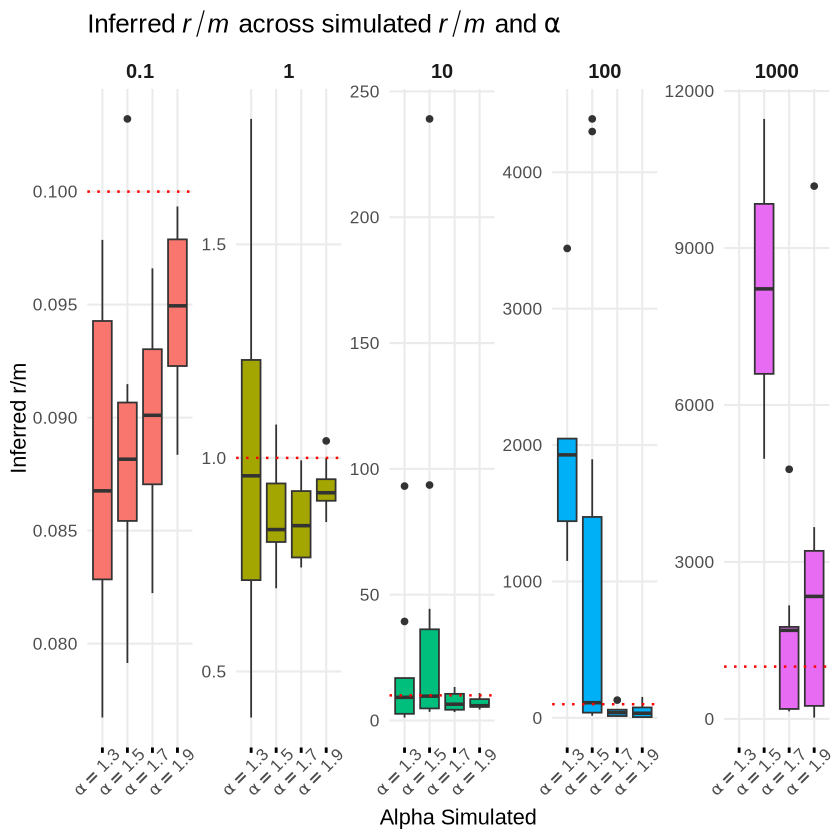

In [19]:
# Define custom labels for each mutation rate
mutation_rate_labels <- c(
  "m1e_6" = "0.1", 
  "m1e_7" = "1", 
  "m1e_8" = "10", 
  "m1e_9" = "100", 
  "m1e_10" = "1000"
)

# Convert MutationRate to a factor with levels in the desired order
all_data_unique$MutationRate <- factor(
  all_data_unique$MutationRate,
  levels = names(mutation_rate_labels)  # Use the order defined in mutation_rate_labels
)

# Create a data frame for horizontal lines
hline_data <- data.frame(
  MutationRate = factor(names(mutation_rate_labels), levels = names(mutation_rate_labels)),  # Match the factor levels
  yintercept = c(0.1, 1, 10, 100, 1000)  # Corresponding y-intercept values
)

# Create the plot
ggplot(all_data_unique, aes(x = alpha_sim, y = r_m, fill = MutationRate)) +
  geom_boxplot() +  # Boxplot
  # Add red dotted lines specific to each facet using data = hline_data
  geom_hline(data = hline_data, aes(yintercept = yintercept), color = "red", linetype = "dotted", size = 0.7) +
  facet_wrap(~ MutationRate, scales = "free_y", ncol = 5, labeller = labeller(MutationRate = mutation_rate_labels)) +  # Custom facet labels
  labs(
    x = "Alpha Simulated",
    y = "Inferred r/m",
    fill = "Mutation Rate",
    title = bquote("Inferred " * italic(r/m) * " across simulated " * italic(r/m) * " and " * alpha)  # Fixed title
  ) +
  scale_x_discrete(labels = x_labels) +  # Apply custom x-axis labels
  theme_minimal(base_size = 13) +
  theme(
    strip.text = element_text(size = 12, face = "bold"),  # Facet labels
    legend.position = "none",
    panel.grid.minor = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 0.75),  # Rotate x-axis labels for better readability
    axis.ticks.x = element_line(size = 0.8),  # Add ticks to x-axis with size
    strip.background = element_blank()  # Remove background from strip text
  )


